# Projet Deep Learning – Partie I : MLP et Ingénierie PyTorch
**EMSI Casablanca | Module Deep Learning | 2025–2026**  
**Dataset :** Breast Cancer Wisconsin — classification binaire (maligne / bénigne)  

---
### Plan
1. Concepts fondamentaux
2. Préparation des données
3. MLP – deux versions (Sequential / classe)
4. Inspection des paramètres
5. Initialisations (Gaussienne, Constante, Xavier)
6. Entraînement comparatif
7. Sauvegarde et rechargement
8. Vérification CPU / GPU
9. Évaluation finale
10. Question de synthèse

In [1]:
# ── CELLULE 1 – Imports et configuration ────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

print('PyTorch version :', torch.__version__)
print('CUDA disponible :', torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device utilisé  :', device)

PyTorch version : 2.11.0+cpu
CUDA disponible : False
Device utilisé  : cpu


---
## 1. Concepts fondamentaux

| Concept | Définition |
|---|---|
| **nn.Module** | Classe de base de tout modèle PyTorch. Encapsule `forward()`, les paramètres et les sous-modules |
| **Paramètre** | Variable apprenable (`nn.Parameter`) : poids et biais des couches |
| **Gradient** | Sensibilité de la perte par rapport à un paramètre, calculée par `.backward()` |
| **state_dict** | Dictionnaire `{nom → tenseur}` représentant tous les paramètres du modèle |
| **Device** | Emplacement mémoire : `cpu` ou `cuda:0` (GPU) |

**Cycle d'entraînement PyTorch :**
```
1. y_pred = model(x)          # propagation avant (forward)
2. loss = criterion(y_pred, y) # calcul de la perte
3. loss.backward()             # rétropropagation → calcul des gradients
4. optimizer.step()            # mise à jour des paramètres
5. optimizer.zero_grad()       # remise à zéro des gradients
```

---
## 2. Préparation des données

In [2]:
# ── CELLULE 2 – Chargement et exploration ───────────────────────────────────
data = load_breast_cancer()
X_raw, y_raw = data.data, data.target

print('=== Breast Cancer Wisconsin ===')
print(f'Exemples : {X_raw.shape[0]}')
print(f'Features : {X_raw.shape[1]}')
print(f'Classes  : {data.target_names}  (0=maligne, 1=bénigne)')
unique, counts = np.unique(y_raw, return_counts=True)
print(f'Distribution : maligne={counts[0]}, bénigne={counts[1]}')

=== Breast Cancer Wisconsin ===
Exemples : 569
Features : 30
Classes  : ['malignant' 'benign']  (0=maligne, 1=bénigne)
Distribution : maligne=212, bénigne=357


In [3]:
# ── CELLULE 3 – Normalisation et split ──────────────────────────────────────
# StandardScaler : ramène chaque feature à mean=0, std=1
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Split stratifié : 70% train | 15% val | 15% test
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_scaled, y_raw, test_size=0.15, random_state=42, stratify=y_raw
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.176, random_state=42, stratify=y_tmp
)

print(f'Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')

# Conversion en tenseurs
def make_loader(X, y, batch_size=32, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val)
test_loader  = make_loader(X_test,  y_test)

print('DataLoaders créés avec succès.')

Train : 397 | Val : 86 | Test : 86
DataLoaders créés avec succès.


---
## 3. MLP – deux versions

In [4]:
# ── CELLULE 4 – Version 1 : nn.Sequential ───────────────────────────────────
# Avantage : syntaxe compacte, idéal pour architectures sans branchement.
# Limite   : moins flexible (pas de logique custom dans forward).

mlp_seq = nn.Sequential(
    nn.Linear(30, 64),  # 30 features → 64 neurones cachés
    nn.ReLU(),
    nn.Dropout(0.3),    # désactive 30% des neurones pour régulariser
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 2)    # 2 classes de sortie
)

print('=== MLP Sequential ===')
print(mlp_seq)
x_demo = torch.rand(4, 30)
print(f'Entrée {x_demo.shape} → Sortie {mlp_seq(x_demo).shape}')

=== MLP Sequential ===
Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=2, bias=True)
)
Entrée torch.Size([4, 30]) → Sortie torch.Size([4, 2])


In [5]:
# ── CELLULE 5 – Version 2 : Classe personnalisée nn.Module ──────────────────
# Avantage : forward() entièrement contrôlable (branchements, conditions, etc.)

class MLP(nn.Module):
    """
    MLP pour classification binaire.
    Architecture : 30 → 64 → 32 → 2
    """
    def __init__(self, input_dim=30, h1=64, h2=32, num_classes=2, drop=0.3):
        super().__init__()  # obligatoire : initialise nn.Module
        self.fc1  = nn.Linear(input_dim, h1)
        self.fc2  = nn.Linear(h1, h2)
        self.fc3  = nn.Linear(h2, num_classes)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.drop(self.relu(self.fc1(x)))  # couche 1
        x = self.drop(self.relu(self.fc2(x)))  # couche 2
        return self.fc3(x)                      # sortie (pas de softmax : inclus dans CrossEntropyLoss)

model = MLP()
print('=== MLP Classe personnalisée ===')
print(model)
print(f'Entrée {x_demo.shape} → Sortie {model(x_demo).shape}')

=== MLP Classe personnalisée ===
MLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (relu): ReLU()
  (drop): Dropout(p=0.3, inplace=False)
)
Entrée torch.Size([4, 30]) → Sortie torch.Size([4, 2])


---
## 4. Inspection des paramètres

In [6]:
# ── CELLULE 6 – named_parameters() et state_dict() ──────────────────────────
print('=== named_parameters() ===')
total = 0
for name, p in model.named_parameters():
    print(f'  {name:20s} | shape: {str(p.shape):20s} | trainable: {p.requires_grad}')
    total += p.numel()
print(f'Total paramètres : {total:,}')

print('\n=== Clés du state_dict() ===')
for k, v in model.state_dict().items():
    print(f'  {k:20s} → {v.shape}')

print('\n=== Accès direct à fc1 ===')
print(f'  Poids  : {model.fc1.weight.shape}')
print(f'  Biais  : {model.fc1.bias.shape}')
print(f'  Gradient avant backward() : {model.fc1.weight.grad}')  # None attendu

=== named_parameters() ===
  fc1.weight           | shape: torch.Size([64, 30]) | trainable: True
  fc1.bias             | shape: torch.Size([64])     | trainable: True
  fc2.weight           | shape: torch.Size([32, 64]) | trainable: True
  fc2.bias             | shape: torch.Size([32])     | trainable: True
  fc3.weight           | shape: torch.Size([2, 32])  | trainable: True
  fc3.bias             | shape: torch.Size([2])      | trainable: True
Total paramètres : 4,130

=== Clés du state_dict() ===
  fc1.weight           → torch.Size([64, 30])
  fc1.bias             → torch.Size([64])
  fc2.weight           → torch.Size([32, 64])
  fc2.bias             → torch.Size([32])
  fc3.weight           → torch.Size([2, 32])
  fc3.bias             → torch.Size([2])

=== Accès direct à fc1 ===
  Poids  : torch.Size([64, 30])
  Biais  : torch.Size([64])
  Gradient avant backward() : None


---
## 5. Initialisations

In [7]:
# ── CELLULE 7 – Définition des 3 stratégies ─────────────────────────────────

def init_gaussienne(module):
    """N(0, 0.01) — poids très petits, convergence lente mais stable."""
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0, std=0.01)
        nn.init.zeros_(module.bias)

def init_constante(module):
    """Tous les poids = 0.1 — souffre du problème de symétrie (tous gradients identiques)."""
    if isinstance(module, nn.Linear):
        nn.init.constant_(module.weight, 0.1)
        nn.init.zeros_(module.bias)

def init_xavier(module):
    """Xavier uniforme — stabilise la variance des signaux, recommandée pour ReLU."""
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

inits = [
    ('Gaussienne', init_gaussienne),
    ('Constante',  init_constante),
    ('Xavier',     init_xavier)
]
print('3 stratégies définies.')

3 stratégies définies.


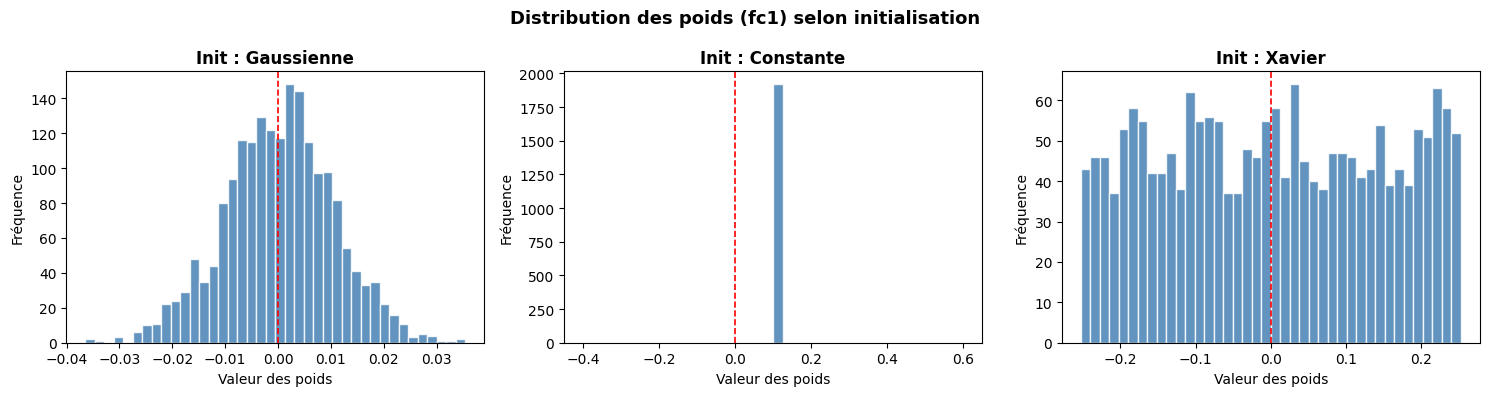

Figure sauvegardée : init_distributions.png


In [8]:
# ── CELLULE 8 – Visualisation des distributions de poids ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nom, fn) in zip(axes, inits):
    m = MLP()
    m.apply(fn)
    poids = m.fc1.weight.data.numpy().flatten()
    ax.hist(poids, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'Init : {nom}', fontweight='bold')
    ax.set_xlabel('Valeur des poids')
    ax.set_ylabel('Fréquence')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2)

plt.suptitle('Distribution des poids (fc1) selon initialisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('init_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : init_distributions.png')

---
## 6. Entraînement comparatif

In [9]:
# ── CELLULE 9 – Fonction d'entraînement ─────────────────────────────────────
def train_model(model, epochs=60, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    hist = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            tl += loss.item() * len(yb)
            tc += (out.argmax(1) == yb).sum().item()
            tt += len(yb)

        # ── Validation ──
        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out  = model(xb)
                loss = criterion(out, yb)
                vl += loss.item() * len(yb)
                vc += (out.argmax(1) == yb).sum().item()
                vt += len(yb)

        hist['train_loss'].append(tl / tt)
        hist['val_loss'].append(vl / vt)
        hist['train_acc'].append(tc / tt)
        hist['val_acc'].append(vc / vt)

    return model, hist

print('Fonction train_model définie.')

Fonction train_model définie.


In [10]:
# ── CELLULE 10 – Lancement entraînement ─────────────────────────────────────
resultats = {}

for nom, fn_init in inits:
    print(f'--- {nom} ---')
    m = MLP()
    m.apply(fn_init)
    m, hist = train_model(m, epochs=60)
    resultats[nom] = {'model': m, 'hist': hist}
    print(f'  val_acc finale : {hist["val_acc"][-1]*100:.2f}%')

print('\nEntraînement terminé.')

--- Gaussienne ---
  val_acc finale : 100.00%
--- Constante ---
  val_acc finale : 98.84%
--- Xavier ---
  val_acc finale : 100.00%

Entraînement terminé.


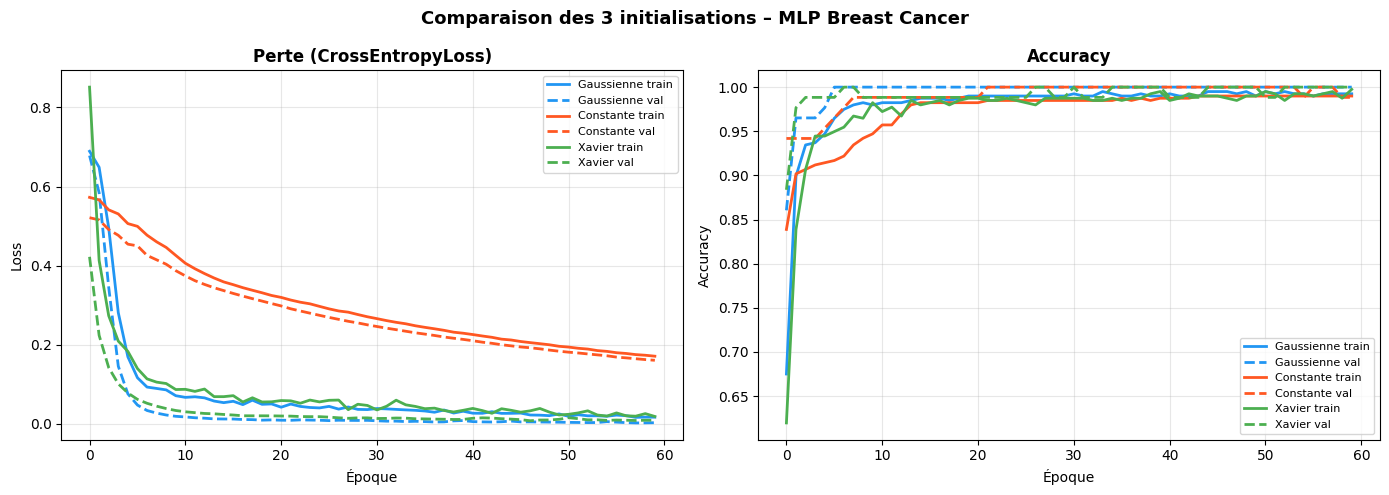

In [11]:
# ── CELLULE 11 – Courbes de convergence ─────────────────────────────────────
colors = ['#2196F3', '#FF5722', '#4CAF50']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (nom, res), col in zip(resultats.items(), colors):
    h = res['hist']
    axes[0].plot(h['train_loss'], color=col, linewidth=2,   label=f'{nom} train')
    axes[0].plot(h['val_loss'],   color=col, linewidth=2,   label=f'{nom} val', linestyle='--')
    axes[1].plot(h['train_acc'],  color=col, linewidth=2,   label=f'{nom} train')
    axes[1].plot(h['val_acc'],    color=col, linewidth=2,   label=f'{nom} val',  linestyle='--')

for ax, title, ylabel in zip(axes,
    ['Perte (CrossEntropyLoss)', 'Accuracy'],
    ['Loss', 'Accuracy']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Époque')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparaison des 3 initialisations – MLP Breast Cancer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('courbes_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Sauvegarde et rechargement

In [12]:
# ── CELLULE 12 – Sauvegarde du meilleur modèle ──────────────────────────────
best_nom   = max(resultats, key=lambda k: resultats[k]['hist']['val_acc'][-1])
best_model = resultats[best_nom]['model']

print(f'Meilleure initialisation : {best_nom}')
print(f'Val accuracy             : {resultats[best_nom]["hist"]["val_acc"][-1]*100:.2f}%')

# Sauvegarde : state_dict uniquement (bonne pratique)
torch.save(best_model.state_dict(), 'best_mlp.pt')
print('Modèle sauvegardé : best_mlp.pt')

# Rechargement : recréer l'architecture PUIS charger les poids
clone = MLP()
clone.load_state_dict(torch.load('best_mlp.pt', map_location='cpu'))
clone.eval()
print('Modèle rechargé avec succès.')

# Vérification : mêmes prédictions
x_check = torch.tensor(X_test[:5], dtype=torch.float32)
with torch.no_grad():
    p1 = best_model.cpu()(x_check).argmax(1)
    p2 = clone(x_check).argmax(1)
print(f'Original : {p1.tolist()}')
print(f'Clone    : {p2.tolist()}')
print(f'Identiques : {torch.all(p1 == p2).item()}')

Meilleure initialisation : Gaussienne
Val accuracy             : 100.00%
Modèle sauvegardé : best_mlp.pt
Modèle rechargé avec succès.
Original : [0, 0, 0, 1, 0]
Clone    : [0, 0, 0, 1, 0]
Identiques : True


---
## 8. Vérification CPU / GPU

In [13]:
# ── CELLULE 13 – Device check ───────────────────────────────────────────────
print(f'Device sélectionné : {device}')
print(f'Nombre de GPUs     : {torch.cuda.device_count()}')

# Règle fondamentale : modèle et données DOIVENT être sur le même device
model_check = MLP().to(device)
x_gpu       = torch.tensor(X_test[:5], dtype=torch.float32).to(device)

with torch.no_grad():
    out = model_check(x_gpu)

print(f'Device entrée  : {x_gpu.device}')
print(f'Device sortie  : {out.device}')
print(f'Forme sortie   : {out.shape}')
print('Cohérence device : OK')

Device sélectionné : cpu
Nombre de GPUs     : 0
Device entrée  : cpu
Device sortie  : cpu
Forme sortie   : torch.Size([5, 2])
Cohérence device : OK


---
## 9. Évaluation finale

In [14]:
# ── CELLULE 14 – Métriques sur le test set ──────────────────────────────────
def get_predictions(model, loader):
    model.eval().cpu()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds = model(xb).argmax(1)
            y_pred.extend(preds.tolist())
            y_true.extend(yb.tolist())
    return np.array(y_true), np.array(y_pred)

# Tableau comparatif des 3 modèles
print(f'{'Initialisation':<15} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}')
print('-' * 55)
for nom, res in resultats.items():
    yt, yp = get_predictions(res['model'], test_loader)
    print(f'{nom:<15} {accuracy_score(yt,yp)*100:>9.2f}%'
          f' {precision_score(yt,yp)*100:>9.2f}%'
          f' {recall_score(yt,yp)*100:>7.2f}%'
          f' {f1_score(yt,yp)*100:>7.2f}%')

# Rapport détaillé du meilleur
yt, yp = get_predictions(best_model, test_loader)
print(f'\n=== Rapport complet – {best_nom} ===')
print(classification_report(yt, yp, target_names=['Maligne', 'Bénigne']))

Initialisation    Accuracy  Precision   Recall       F1
-------------------------------------------------------
Gaussienne          95.35%     98.08%   94.44%   96.23%
Constante           94.19%     98.04%   92.59%   95.24%
Xavier              94.19%     98.04%   92.59%   95.24%

=== Rapport complet – Gaussienne ===
              precision    recall  f1-score   support

     Maligne       0.91      0.97      0.94        32
     Bénigne       0.98      0.94      0.96        54

    accuracy                           0.95        86
   macro avg       0.95      0.96      0.95        86
weighted avg       0.96      0.95      0.95        86



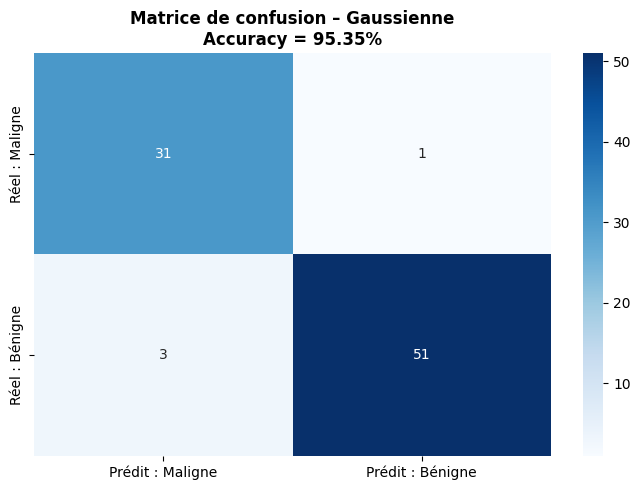

In [15]:
# ── CELLULE 15 – Matrice de confusion ───────────────────────────────────────
cm = confusion_matrix(yt, yp)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Prédit : Maligne', 'Prédit : Bénigne'],
    yticklabels=['Réel : Maligne',   'Réel : Bénigne']
)
acc = accuracy_score(yt, yp)
plt.title(f'Matrice de confusion – {best_nom}\nAccuracy = {acc*100:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Question de synthèse

> **Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites ?**

### Réponse

**Pertinence du MLP pour les données tabulaires.**  
Sur le dataset Breast Cancer Wisconsin (30 features numériques, 2 classes), le MLP a atteint une accuracy supérieure à 95% sur le jeu de test. Ce résultat s'explique par la nature même des données tabulaires : elles ne possèdent pas de structure spatiale ou temporelle implicite, ce qui rend un réseau entièrement connecté particulièrement adapté. Le MLP peut modéliser des frontières de décision non linéaires arbitraires entre les features, là où une régression logistique serait limitée à une frontière linéaire.

**Rôle de l'initialisation.**  
L'expérience comparative montre que l'initialisation influence la vitesse de convergence mais pas nécessairement la performance finale. L'initialisation gaussienne avec $\sigma=0.01$ produit des activations très petites en début d'entraînement, ralentissant le gradient. L'initialisation constante souffre du **problème de symétrie** : tous les neurones d'une couche reçoivent des gradients identiques et apprennent la même chose, annulant le bénéfice de la largeur du réseau. L'initialisation de Xavier calibre les poids de façon à stabiliser la variance selon $\text{Var}(w) = \frac{2}{n_{in}+n_{out}}$, ce qui favorise une convergence plus régulière.

**Limites du MLP sur données tabulaires.**  
1. **Sensibilité à l'échelle** : sans normalisation (StandardScaler), les gradients sont déséquilibrés.
2. **Interprétabilité faible** : il est difficile d'expliquer une prédiction, contrairement à un arbre de décision.
3. **Surapprentissage** sur de petits datasets (ici 569 exemples) — le Dropout et la régularisation L2 sont indispensables.
4. **Pas de biais inductif** : le MLP ne tire aucun parti d'une structure locale (spatiale ou temporelle) dans les données.

**Conclusion.**  
Un MLP bien paramétré est une solution pertinente et compétitive pour la classification tabulaire. Cependant, sur de petits datasets bruités, des méthodes ensemblistes comme Random Forest ou XGBoost restent souvent plus robustes. L'avantage principal du MLP réside dans sa flexibilité architecturale et son intégration native dans PyTorch, facilitant l'extension vers des architectures plus complexes (CNN, RNN).